# Transformers & Attention — A Visual Walkthrough

**ANLP Session 6 — Transformers & Language Models**

---

The Transformer is the architecture behind BERT, GPT, and virtually every modern language model. Its defining feature is **self-attention** — a mechanism that lets every word in a sentence look at every other word simultaneously.

Rather than explaining this with equations, this notebook lets you *see* attention working inside a real BERT model. We will:

1. Understand what attention is (in plain terms)
2. Extract attention weights from BERT on a real sentence
3. Visualise a single attention head
4. See how 12 heads in the same layer each learn different patterns
5. Watch how BERT resolves the pronoun *"it"* across layers

---

## Part 1 — What is Attention?

When you read the sentence *"The trophy didn't fit in the suitcase because it was too big"*, you instantly know that *"it"* refers to the trophy, not the suitcase. You resolved that by attending to earlier words — weighing how relevant each one was to understanding *"it"*.

Self-attention does the same thing, but for every word simultaneously.

For each token in the sequence, the model asks:

> *"How much should I look at every other token when building my representation?"*

The answer is a set of weights — one per token — that sum to 1. Think of it as a probability distribution over the sequence:

```
Token: "it"

  The    trophy  didn't   fit    in    the  suitcase  because   it   was   too   big
  0.02   0.41    0.03    0.05   0.01   0.01   0.18      0.08    0.12  0.04  0.01  0.04
  ░░░    ████    ░░░     ░░░    ░       ░     ███       ░░       ██   ░     ░     ░
```

The model is paying most attention to *"trophy"* when processing *"it"* — which is exactly the right answer.

**Multi-head attention** simply runs this process in parallel with different learned weight matrices — each *head* can specialise in a different type of relationship (syntax, coreference, position, etc.).

**Layers** stack on top of each other. Early layers tend to capture local and syntactic patterns; later layers capture longer-range semantic relationships.

---

## Part 2 — Setup

In [50]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import logging
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import transformers
transformers.logging.set_verbosity_error()
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# attn_implementation="eager" uses the standard attention implementation.
# Newer versions of transformers default to "sdpa" (PyTorch's fused kernel)
# which runs faster but does not expose the attention weight matrices.
# We need "eager" so we can inspect what the model is attending to.
model = BertModel.from_pretrained("bert-base-uncased", attn_implementation="eager")
model.config.output_attentions = True
model.eval()

print("Ready.")
print(f"Layers: {model.config.num_hidden_layers}, Heads per layer: {model.config.num_attention_heads}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Ready.
Layers: 12, Heads per layer: 12


---

## Part 3 — Extracting Attention Weights

BERT has **12 layers**, each with **12 attention heads**. When we pass a sentence through the model, we can ask it to return all the attention weights by setting `output_attentions=True`.

Each layer returns a tensor of shape:
```
(batch_size, num_heads, sequence_length, sequence_length)
```

The value at position `[head, i, j]` answers: *"when processing token i, how much attention did head pay to token j?"*

Let's run a simple sentence through and inspect the shapes.

In [55]:
sentence = "The cat sat on the mat near the window."

inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

# outputs.attentions is a tuple of 12 tensors, one per layer
attentions = outputs.attentions

print(f"Tokens      : {tokens}")
print(f"Num tokens  : {len(tokens)}")
print(f"Num layers  : {len(attentions)}")
print(f"Shape of one layer's attention: {attentions[0].shape}")
print("  → (batch=1, heads=12, seq_len, seq_len)")

Tokens      : ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'near', 'the', 'window', '.', '[SEP]']
Num tokens  : 12
Num layers  : 12
Shape of one layer's attention: torch.Size([1, 12, 12, 12])
  → (batch=1, heads=12, seq_len, seq_len)


---

## Part 4 — Visualising a Single Attention Head

Let's look at one head in one layer. The heatmap shows the full attention matrix — rows are the tokens *doing the attending*, columns are the tokens *being attended to*.

A bright cell at row `i`, column `j` means: *"token i paid a lot of attention to token j."*

Each row sums to **1.0** — every token distributes its full attention budget across all other tokens including `[CLS]` and `[SEP]`.

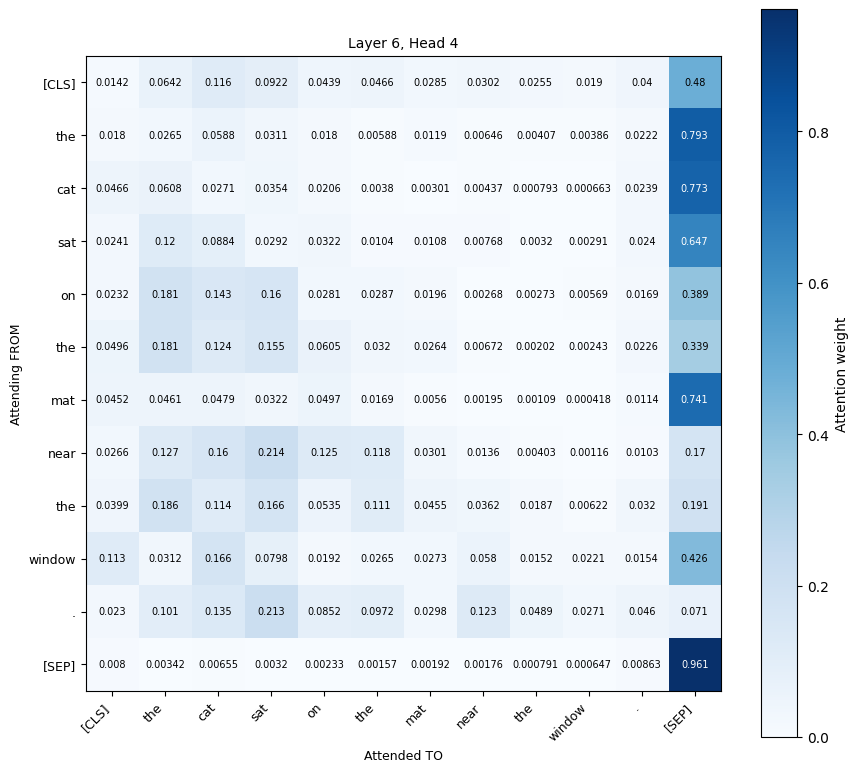

In [56]:
def plot_attention_head(tokens, attention_matrix, layer, head, ax=None, show_values=True):
    """
    Plot a single attention head as a heatmap.

    Parameters
    ----------
    show_values : bool
        If True, print the attention weight as a number in each cell.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    im = ax.imshow(attention_matrix, cmap="Blues", vmin=0, vmax=attention_matrix.max())

    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel("Attended TO", fontsize=9)
    ax.set_ylabel("Attending FROM", fontsize=9)
    ax.set_title(f"Layer {layer+1}, Head {head+1}", fontsize=10)

    if show_values:
        threshold = attention_matrix.max() * 0.6
        for i in range(attention_matrix.shape[0]):
            for j in range(attention_matrix.shape[1]):
                val = attention_matrix[i, j]
                colour = "white" if val > threshold else "black"
                ax.text(j, i, f"{val:.3g}", ha="center", va="center",
                        fontsize=7, color=colour)

    return im


LAYER, HEAD = 5, 3
attn = attentions[LAYER][0, HEAD].numpy()

fig, ax = plt.subplots(figsize=(9, 8))
im = plot_attention_head(tokens, attn, LAYER, HEAD, ax=ax, show_values=True)
plt.colorbar(im, ax=ax, label="Attention weight")
plt.tight_layout()
plt.show()

**What to look for:**
- A bright diagonal means tokens are attending mostly to themselves (common in lower layers).
- Bright cells off the diagonal mean a token is drawing heavily from a distant word.
- `[CLS]` and `[SEP]` often absorb a lot of attention — they act as "sinks" that the model uses to pool global information.

Try changing `LAYER` (0–11) and `HEAD` (0–11) above and re-running to explore different patterns.

---

## Part 5 — All 12 Heads in One Layer

Each of the 12 heads in a layer learns a *different* attention pattern. This is the point of multi-head attention — by running multiple attention operations in parallel, the model can simultaneously track different types of relationships.

Let's look at all 12 heads in a single layer at once.

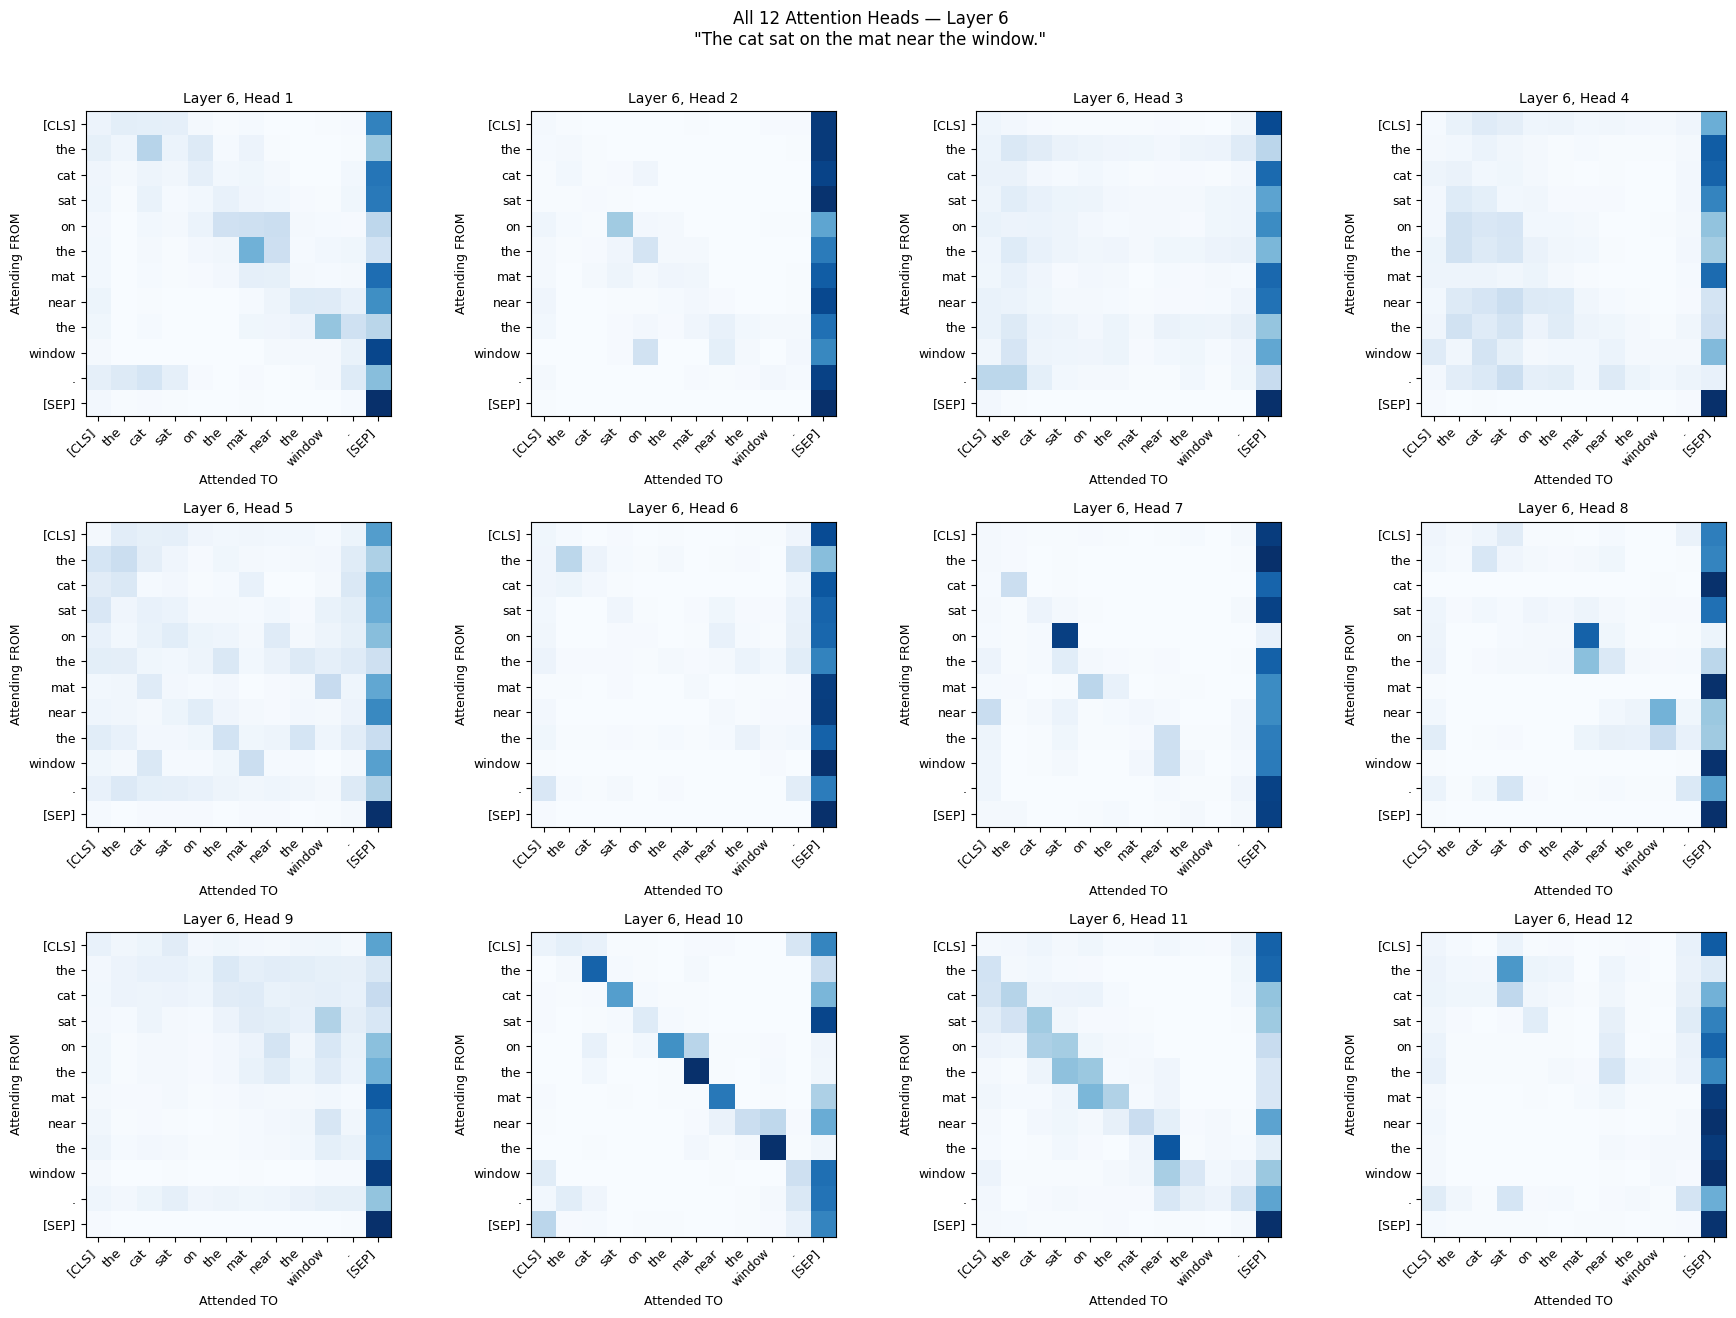

Each panel is one head. Notice how different they look — some attend locally, some globally, some focus on [CLS]/[SEP].


In [57]:
LAYER = 5  # try changing this to 0 (early) or 11 (late)

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle(f"All 12 Attention Heads — Layer {LAYER+1}\n\"{sentence}\"",
             fontsize=12, y=1.01)

for head in range(12):
    ax = axes[head // 4][head % 4]
    attn = attentions[LAYER][0, head].numpy()
    plot_attention_head(tokens, attn, LAYER, head, ax=ax,   show_values=False)

plt.tight_layout()
plt.show()

print("Each panel is one head. Notice how different they look — "
      "some attend locally, some globally, some focus on [CLS]/[SEP].")

**What to notice across heads:**
- Some heads attend very locally — each token mostly looks at its immediate neighbours.
- Some heads attend to `[CLS]` from almost everywhere — using it as a global information bus.
- Some heads show strong vertical stripes — many tokens attending heavily to one particular token.
- No two heads are the same — this diversity is what gives the Transformer its expressive power.

Change `LAYER` to `0` and re-run. Then try `11`. You will see that early layers tend to have more uniform, positional patterns, while later layers show more selective, meaning-driven attention.

---

## Part 6 — The "Wow" Example: Pronoun Resolution

Now for the most compelling demonstration. Consider this sentence:

> *"The dog chased the cat because **it** was scared."*

What does *"it"* refer to? The cat — it was scared, that's why it ran. Resolving this requires understanding the semantics of "chased" and "scared" and which entity is more likely to be the scared one.

Let's look at how much attention the token `"it"` pays to every other token, and watch how that changes across BERT's 12 layers.

In [58]:
pronoun_sentence = "The dog chased the cat because it was scared."

pronoun_inputs = tokenizer(pronoun_sentence, return_tensors="pt")
pronoun_tokens = tokenizer.convert_ids_to_tokens(pronoun_inputs["input_ids"][0])

with torch.no_grad():
    pronoun_outputs = pronoun_inputs = tokenizer(pronoun_sentence, return_tensors="pt")
    pronoun_outputs = model(**pronoun_inputs, output_attentions=True)

pronoun_attentions = pronoun_outputs.attentions

# Find the index of "it" in the token list
it_idx = pronoun_tokens.index("it")

print(f"Tokens : {pronoun_tokens}")
print(f"'it' is at position {it_idx}")

Tokens : ['[CLS]', 'the', 'dog', 'chased', 'the', 'cat', 'because', 'it', 'was', 'scared', '.', '[SEP]']
'it' is at position 7


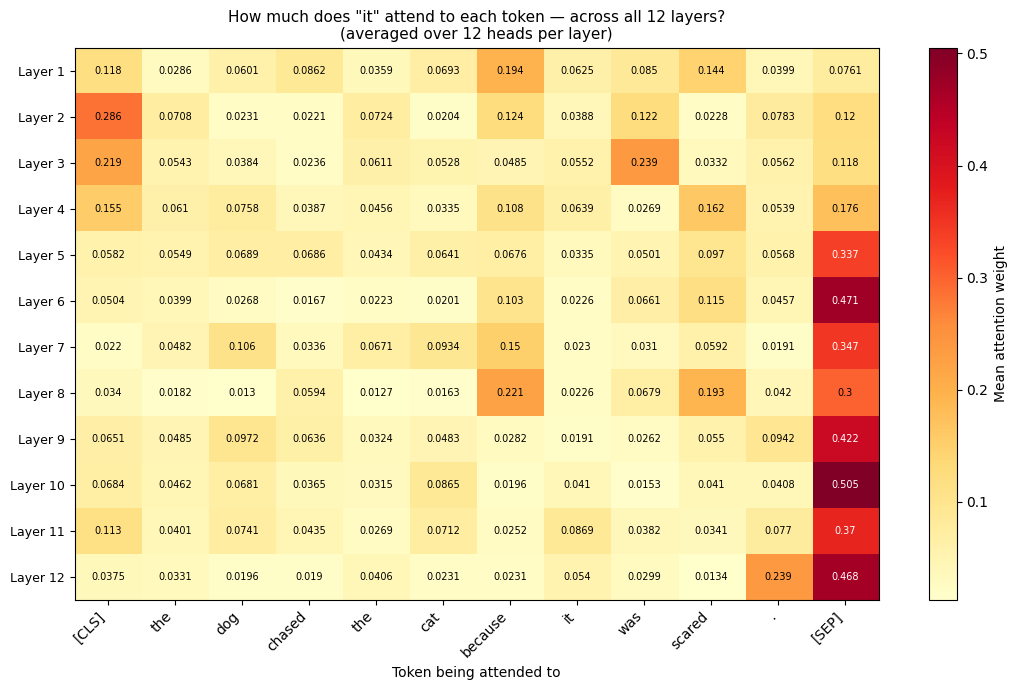

In [59]:
def get_token_attention_over_layers(attentions, token_idx):
    """Return a (num_layers, seq_len) array: attention from token_idx to all others, per layer."""
    rows = []
    for layer_attn in attentions:
        avg_heads = layer_attn[0].mean(dim=0).numpy()
        rows.append(avg_heads[token_idx])
    return np.array(rows)  # (num_layers, seq_len)


def plot_attention_heatmap(tokens, attention_grid, title, show_values=True):
    """
    Plot a (num_layers, seq_len) attention heatmap.

    Parameters
    ----------
    show_values : bool
        If True, print the attention weight as a number in each cell.
    """
    fig, ax = plt.subplots(figsize=(11, 7))
    im = ax.imshow(attention_grid, cmap="YlOrRd", aspect="auto")

    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=10)
    ax.set_yticks(range(12))
    ax.set_yticklabels([f"Layer {i+1}" for i in range(12)], fontsize=9)
    ax.set_xlabel("Token being attended to", fontsize=10)
    ax.set_title(title, fontsize=11)

    if show_values:
        threshold = attention_grid.max() * 0.6
        for i in range(attention_grid.shape[0]):
            for j in range(attention_grid.shape[1]):
                val = attention_grid[i, j]
                colour = "white" if val > threshold else "black"
                ax.text(j, i, f"{val:.3g}", ha="center", va="center",
                        fontsize=7, color=colour)

    plt.colorbar(im, ax=ax, label="Mean attention weight")
    plt.tight_layout()
    plt.show()


it_attention = get_token_attention_over_layers(pronoun_attentions, it_idx)

# Use full token list including [CLS] and [SEP] — rows now sum to 1.0
plot_attention_heatmap(
    tokens=pronoun_tokens,
    attention_grid=it_attention,
    title='How much does "it" attend to each token — across all 12 layers?\n(averaged over 12 heads per layer)',
    show_values=True,
    )

**What to look for:**

- In the **early layers** (1–4), attention is fairly spread out or focused on nearby tokens — the model is still processing basic structure.
- In the **middle and later layers** (6–12), watch whether `"cat"` or `"dog"` receives stronger attention from `"it"`. BERT should lean toward `"cat"` — the entity more plausibly associated with being scared.
- `[CLS]` often lights up in later layers as a global summary token.

This progression — from local/structural in early layers to semantic/long-range in later layers — is one of the most important empirical findings about how Transformers work.

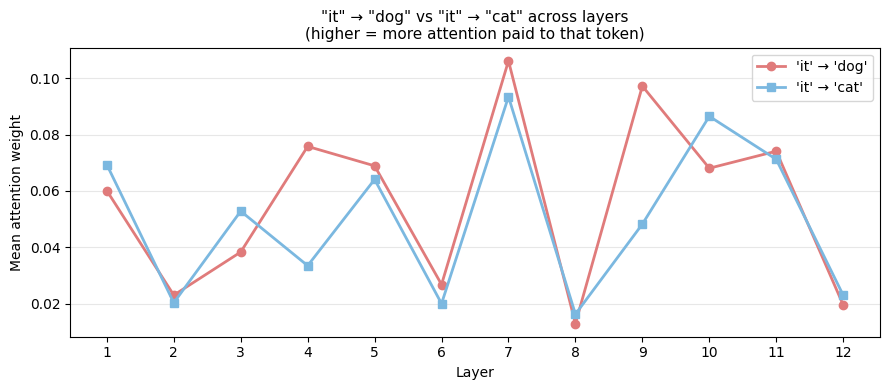

In the final layer, 'it' attends more to 'cat'.
  → 'dog': 0.0196
  → 'cat': 0.0231


In [60]:
# Zoom in: compare attention to 'dog' vs 'cat' from 'it', layer by layer
dog_idx = pronoun_tokens.index("dog")
cat_idx = pronoun_tokens.index("cat")

attn_to_dog = it_attention[:, dog_idx]
attn_to_cat = it_attention[:, cat_idx]

layers = range(1, 13)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(layers, attn_to_dog, marker="o", label="'it' → 'dog'", color="#e07b7b", linewidth=2)
ax.plot(layers, attn_to_cat, marker="s", label="'it' → 'cat'", color="#7bb8e0", linewidth=2)
ax.set_xlabel("Layer", fontsize=10)
ax.set_ylabel("Mean attention weight", fontsize=10)
ax.set_title('"it" → "dog" vs "it" → "cat" across layers\n'
             '(higher = more attention paid to that token)', fontsize=11)
ax.set_xticks(layers)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Print which entity wins in the final layer
winner = "cat" if attn_to_cat[-1] > attn_to_dog[-1] else "dog"
print(f"In the final layer, 'it' attends more to '{winner}'.")
print(f"  → 'dog': {attn_to_dog[-1]:.4f}")
print(f"  → 'cat': {attn_to_cat[-1]:.4f}")

---

## Summary

| What we saw | What it means |
|---|---|
| Attention is a weight matrix over tokens | Each token decides how much to "look at" every other token |
| 12 heads per layer, all different | Each head specialises in a different relationship type |
| Early layers: local/structural | Tokens attend to neighbours and positional context |
| Later layers: semantic/long-range | Tokens attend based on meaning and discourse relationships |
| Pronoun resolution emerges in later layers | The model builds up context gradually — it doesn't just pattern match |

The key insight is that there is no fixed rule about which word attends to which — **the attention weights are learned from data**. BERT learned to resolve pronouns, track entities, and understand syntax purely by being trained to predict masked words across billions of sentences.

This is what makes Transformers fundamentally different from all the models that came before them.